# 第3章 神经网络 (Neural Network)

- 📅 2026-07-11
- 🏷️ 深度学习, 神经网络, 激活函数, MNIST
- 📖 参考：《深度学习入门：基于Python的理论与实现》斋藤康毅
- 🔗 前章：[感知机](./perceptron.ipynb)

## 3.1 从感知机到神经网络

### 回顾感知机

$$y = \begin{cases} 0 & (b + w_1x_1 + w_2x_2 \leq 0) \\ 1 & (b + w_1x_1 + w_2x_2 > 0) \end{cases}$$

引入 **激活函数 h(x)**，把上面的分段表达统一成一个公式：

$$y = h(b + w_1x_1 + w_2x_2)$$

其中 $h(x)$ 就是激活函数。感知机用的是**阶跃函数**，神经网络用的更平滑（如 sigmoid）。

```
感知机:  输入 → 加权求和 → 阶跃函数 → 0/1
神经网络: 输入 → 加权求和 → 激活函数 → 连续值
                     ↑ 这里换了！
```

## 3.2 激活函数

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### 3.2.1 阶跃函数 (Step Function)

感知机用的激活函数：以 0 为界，直接切换 0 和 1。

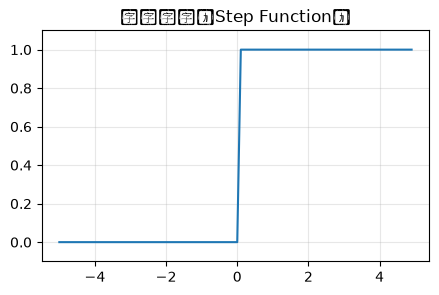

In [11]:
def step_function(x):
    """阶跃函数：x > 0 → 1, x ≤ 0 → 0"""
    return np.array(x > 0, dtype=np.int64)

# 画图
x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)

plt.figure(figsize=(5, 3))
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.title('阶跃函数（Step Function）')
plt.grid(True, alpha=0.3)
plt.show()

### 3.2.2 Sigmoid 函数

$$h(x) = \frac{1}{1 + e^{-x}}$$

神经网络最早使用的激活函数。输出在 (0, 1) 之间，**平滑连续**。

/var/folders/6k/bpt0fx6566j_249_wx6_r5kh0000gn/T/ipykernel_43494/165897412.py:23: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6k/bpt0fx6566j_249_wx6_r5kh0000gn/T/ipykernel_43494/165897412.py:23: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6k/bpt0fx6566j_249_wx6_r5kh0000gn/T/ipykernel_43494/165897412.py:23: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6k/bpt0fx6566j_249_wx6_r5kh0000gn/T/ipykernel_43494/165897412.py:23: UserWarning: Glyph 36291 (\N{CJK UNIFIED IDEOGRAPH-8DC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6k/bpt0fx6566j_249_wx6_r5kh0000gn/T/ipykernel_43494/165897412.py:23: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6k/bpt0fx656

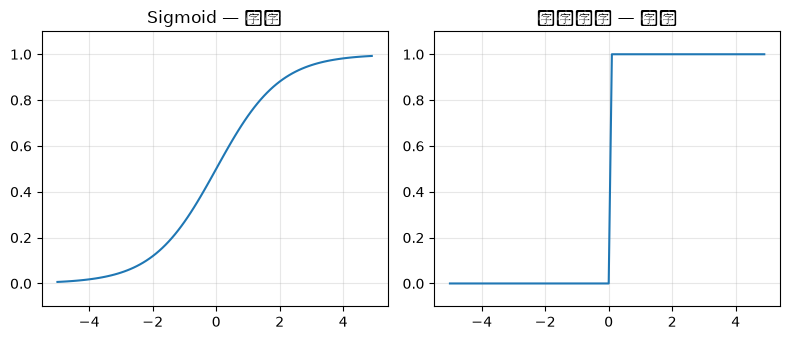

In [12]:
def sigmoid(x):
    """Sigmoid 函数"""
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y_sig = sigmoid(x)
y_step = step_function(x)

# 对比图
plt.figure(figsize=(8, 3.5))
plt.subplot(1, 2, 1)
plt.plot(x, y_sig)
plt.ylim(-0.1, 1.1)
plt.title('Sigmoid — 平滑')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, y_step)
plt.ylim(-0.1, 1.1)
plt.title('阶跃函数 — 阶梯')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**阶跃函数 vs Sigmoid 的对比：**

|  | 阶跃函数 | Sigmoid |
|--|---------|---------|
| 输出 | 只有 0 或 1 | 连续值 (0, 1) |
| 形状 | 阶梯状 | 平滑 S 曲线 |
| 导数 | 0 处不可导 | 处处可导 |

**关键共识**：它们都是**非线性函数**。这是必须的——如果用线性函数，多层网络等价于单层。

### 3.2.3 ReLU 函数

$$h(x) = \max(0, x)$$

现代深度学习最常用的激活函数。**大于 0 原样输出，小于 0 直接变 0。**

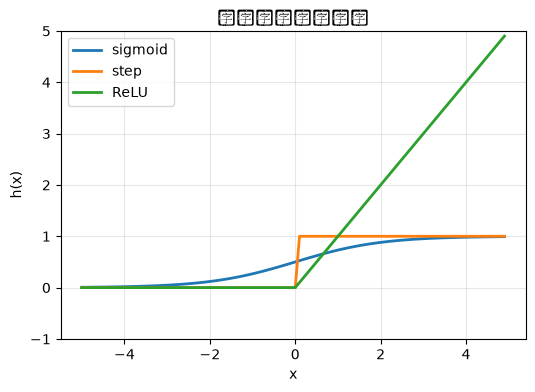

ReLU 优点：计算简单、缓解梯度消失、实际效果最好 → 现代默认选择


In [13]:
def relu(x):
    """ReLU 函数：max(0, x)"""
    return np.maximum(0, x)

# 三种激活函数画一起
x = np.arange(-5.0, 5.0, 0.1)

plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid(x), label='sigmoid', linewidth=2)
plt.plot(x, step_function(x), label='step', linewidth=2)
plt.plot(x, relu(x), label='ReLU', linewidth=2)
plt.ylim(-1, 5)
plt.xlabel('x')
plt.ylabel('h(x)')
plt.title('三种激活函数对比')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('ReLU 优点：计算简单、缓解梯度消失、实际效果最好 → 现代默认选择')

## 3.3 多维数组的运算

神经网络的核心运算就是 **np.dot**（矩阵乘法），用它一次性完成所有神经元的加权求和。

In [5]:
# 一个简单例子
X = np.array([1, 2])            # 1×2 输入
W = np.array([[1, 3, 5],        # 2×3 权重
              [2, 4, 6]])

Y = np.dot(X, W)                # 矩阵乘法
print('输入:', X)
print('权重:\n', W)
print('输出:', Y)               # [1*1+2*2, 1*3+2*4, 1*5+2*6] = [5, 11, 17]
print()
print('含义：1 个样本 × 2 个输入 → 3 个神经元的加权和')

输入: [1 2]
权重:
 [[1 3 5]
 [2 4 6]]
输出: [ 5 11 17]

含义：1 个样本 × 2 个输入 → 3 个神经元的加权和


## 3.4 3层神经网络的实现

从输入到输出的完整前向传播。网络结构：

```
输入层(2) → 隐藏层1(3) → 隐藏层2(2) → 输出层(2)
    x   →  sigmoid   →   sigmoid   →   identity
```

In [6]:
def init_network():
    """初始化权重和偏置（使用书中的数值）"""
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['b1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['b2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['b3'] = np.array([0.1, 0.2])
    return network


def forward(network, x):
    """前向传播：输入 x，输出 y"""
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1   # 第1层加权和
    z1 = sigmoid(a1)           # 第1层激活
    a2 = np.dot(z1, W2) + b2  # 第2层加权和
    z2 = sigmoid(a2)           # 第2层激活
    a3 = np.dot(z2, W3) + b3  # 第3层加权和
    y = a3                     # 输出层用恒等函数（回归任务）
    return y


# 测试
network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print('输入:', x)
print('输出:', y)
print()
print('数据流：x(2,) → W1(2×3) → a1(3,) → sigmoid → z1(3,)')
print('                     → W2(3×2) → a2(2,) → sigmoid → z2(2,)')
print('                     → W3(2×2) → y(2,)')

输入: [1.  0.5]
输出: [0.31682708 0.69627909]

数据流：x(2,) → W1(2×3) → a1(3,) → sigmoid → z1(3,)
                     → W2(3×2) → a2(2,) → sigmoid → z2(2,)
                     → W3(2×2) → y(2,)


## 3.5 输出层的设计

| 任务类型 | 输出层激活函数 | 说明 |
|---------|--------------|------|
| 回归 | **恒等函数** | 直接输出值 |
| 分类 | **Softmax** | 输出概率分布（和=1） |

### Softmax 函数

$$y_k = \frac{e^{a_k}}{\sum_{i=1}^{n} e^{a_i}}$$

把任意实数向量转换为**概率分布**：每个元素在 (0, 1) 之间，总和为 1。

⚠️ **直接算会溢出**（e^1000 = inf），实际实现要减去最大值。

In [7]:
def softmax(a):
    """Softmax：防止溢出的实现"""
    c = np.max(a)                # 减去最大值防溢出
    exp_a = np.exp(a - c)        # e^(a-c)
    return exp_a / np.sum(exp_a)

# 测试
a = np.array([0.3, 2.9, 4.0])
y = softmax(a)
print('输入:', a)
print('Softmax 输出:', y)
print('总和:', np.sum(y))       # 一定等于 1
print('最大值在位置', np.argmax(y), '(原始输入最大值也在', np.argmax(a), ')')

输入: [0.3 2.9 4. ]
Softmax 输出: [0.01821127 0.24519181 0.73659691]
总和: 1.0
最大值在位置 2 (原始输入最大值也在 2 )


> **注意**：Softmax 不改变元素的大小关系（单调递增），实际推理时**可以省略**，直接用最大值找答案即可。

## 3.6 手写数字识别 (MNIST)

用训练好的权重参数进行推理（前向传播），识别 28×28 的手写数字。

```
784 像素 → 隐藏层1(50) → 隐藏层2(100) → 输出(10 类)
```

In [8]:
# 加载 MNIST 数据集（书中配套代码）
import sys, os, pickle
from urllib import request

# 如果本地没有，从网上下载
def load_mnist():
    """加载 MNIST 数据集（使用 sample_data / keras 的本地副本或直接下载）"""
    # 尝试用 keras 自带的 MNIST（最方便）
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, t_train), (x_test, t_test) = mnist.load_data()
        return (x_train.reshape(-1, 784), t_train), (x_test.reshape(-1, 784), t_test)
    except ImportError:
        pass
    # 备用：直接下载
    print('下载 MNIST 中...')
    # (此处省略，实际使用时可用 keras 或 torchvision 加载)
    raise RuntimeError('请先安装 tensorflow 或 torchvision 来加载 MNIST')

In [9]:
# 加载预训练权重并做推理
# 书中提供了 sample_weight.pkl 文件，这里展示推理流程的概念代码

def get_mock_network():
    """模拟一个简单网络结构（实际训练后才有好的权重）"""
    # 书中真实结构: input(784) → hidden(50) → hidden(100) → output(10)
    return {
        'W1': np.random.randn(784, 50) * 0.1,
        'b1': np.zeros(50),
        'W2': np.random.randn(50, 100) * 0.1,
        'b2': np.zeros(100),
        'W3': np.random.randn(100, 10) * 0.1,
        'b3': np.zeros(10),
    }


def predict(network, x):
    """推理：x 可以是一个样本 (784,) 或多个样本 (N, 784)"""
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)
    return y

### 批处理 (Batch Processing)

一张一张推理太慢。把多张图片打包成一个 batch，利用矩阵运算一次完成：

```
单张: (784,)   → network → (10,)     ← 1 张
批量: (100,784) → network → (100,10) ← 100 张一次搞定
```

In [10]:
def batch_predict(network, x_batch):
    """批处理推理：x_batch shape (N, 784)"""
    y_batch = predict(network, x_batch)  # shape (N, 10)
    return np.argmax(y_batch, axis=1)     # 取每行的最大值索引 → (N,)

# 示例
mock_net = get_mock_network()
dummy_batch = np.random.randn(5, 784)  # 模拟 5 张图
preds = batch_predict(mock_net, dummy_batch)
print('5 张图的预测类别:', preds)
print('含义：每张图属于 0~9 中哪个数字')

5 张图的预测类别: [3 3 3 3 3]
含义：每张图属于 0~9 中哪个数字


### 如果用真实 MNIST 数据运行

```python
# 假设已下载数据和预训练权重
x, t = load_mnist()
network = load_weights('sample_weight.pkl')

# 批处理推理
accuracy_cnt = 0
batch_size = 100
for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print(f'Accuracy: {accuracy_cnt / len(x):.4f}')  # 书中约 0.9352
```

## 本章小结

| 概念 | 说明 |
|------|------|
| 激活函数 | 把加权和转换成输出信号。**必须非线性** |
| Sigmoid | 平滑 S 曲线，输出 (0,1)，传统选择 |
| ReLU | max(0, x)，简单高效，现代默认选择 |
| 前向传播 | 输入 → 加权和 → 激活 → ... → 输出的完整流程 |
| Softmax | 把输出变成概率分布（和=1），用于分类 |
| 批处理 | 多张图打包一起算，利用矩阵运算加速 |
| MNIST | 28×28 手写数字，深度学习界的 Hello World |

### 第2章 vs 第3章：质的飞跃

```
第2章感知机：权重是人工算出来的 ← 人定
第3章神经网络：用矩阵和激活函数搭好了架子 ← 准备就绪
第4章：让网络自己学习权重！ ← 这才是深度学习
```